In [1]:
from pathlib import Path
import pandas as pd

data_dir = Path("../data")

acc_files = sorted(data_dir.glob("acc_*.csv"))

acc_files

[PosixPath('../data/acc_16.csv'),
 PosixPath('../data/acc_17.csv'),
 PosixPath('../data/acc_18.csv'),
 PosixPath('../data/acc_19.csv'),
 PosixPath('../data/acc_20.csv')]

In [2]:
accidents = pd.concat(
    [pd.read_csv(file) for file in acc_files],
    ignore_index=True,
    join="inner"
)

print(accidents.shape)

accidents["YEAR"].value_counts().sort_index()

/var/folders/_q/js38qlc91xb1m7kk9s0cjqcm0000gn/T/ipykernel_89657/4219171968.py:2: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(file) for file in acc_files],


(259077, 45)


YEAR
2016    46511
2017    54969
2018    48443
2019    54409
2020    54745
Name: count, dtype: int64

In [3]:
print(accidents.columns.tolist())

['CASENUM', 'PSU', 'PJ', 'STRATUM', 'VE_TOTAL', 'VE_FORMS', 'PVH_INVL', 'PEDS', 'PERMVIT', 'PERNOTMVIT', 'NUM_INJ', 'MONTH', 'YEAR', 'DAY_WEEK', 'HOUR', 'MINUTE', 'HARM_EV', 'ALCOHOL', 'MAX_SEV', 'MAN_COLL', 'RELJCT1', 'RELJCT2', 'TYP_INT', 'WRK_ZONE', 'REL_ROAD', 'LGT_COND', 'WEATHER', 'SCH_BUS', 'INT_HWY', 'WKDY_IM', 'HOUR_IM', 'MINUTE_IM', 'EVENT1_IM', 'MANCOL_IM', 'RELJCT2_IM', 'LGTCON_IM', 'WEATHR_IM', 'MAXSEV_IM', 'NO_INJ_IM', 'ALCHL_IM', 'URBANICITY', 'REGION', 'PSUSTRAT', 'PSU_VAR', 'WEIGHT']


In [4]:
# Serious injury or fatal crash
accidents["severe_crash"] = accidents["MAXSEV_IM"].isin([3, 4])

# Fatal crash only
accidents["fatal_crash"] = accidents["MAXSEV_IM"] == 4

# Weekend: 1 = Sunday, 7 = Saturday
accidents["weekend"] = accidents["WKDY_IM"].isin([1, 7])

# Alcohol involved: 1 = involved, 2 = not involved
accidents["alcohol_involved"] = accidents["ALCHL_IM"] == 1

# Dark conditions: 2 = not lighted, 3 = lighted, 6 = unknown lighting
accidents["dark"] = accidents["LGTCON_IM"].isin([2, 3, 6])

# Rural: 1 = urban, 2 = rural
accidents["rural"] = accidents["URBANICITY"] == 2

accidents[["severe_crash", "fatal_crash", "weekend",
           "alcohol_involved", "dark", "rural"]].sum()

severe_crash        32771
fatal_crash          5228
weekend             61925
alcohol_involved    15571
dark                70648
rural               60489
dtype: int64

### Engineer dayparts

Group each crash into a time period while preserving chronological order.

In [5]:
daypart_labels = [
    "Late night",
    "Morning commute",
    "Midday",
    "Evening commute",
    "Night",
]

assert accidents["HOUR_IM"].between(0, 23).all()

accidents["daypart"] = pd.cut(
    accidents["HOUR_IM"],
    bins=[-1, 5, 9, 15, 19, 23],
    labels=daypart_labels,
    ordered=True,
)

accidents["daypart"].value_counts(sort=False)

daypart
Late night         20484
Morning commute    43572
Midday             90758
Evening commute    72668
Night              31595
Name: count, dtype: int64

### Build weighted summaries

Use the CRSS case weight to estimate national crash totals and severity rates.

In [6]:
def weighted_summary(df, group_col):
    summary_data = df.loc[
        df[group_col].notna() & df["WEIGHT"].notna(),
        [group_col, "WEIGHT", "severe_crash", "fatal_crash"],
    ].copy()

    summary_data["weighted_severe"] = (
        summary_data["severe_crash"] * summary_data["WEIGHT"]
    )
    summary_data["weighted_fatal"] = (
        summary_data["fatal_crash"] * summary_data["WEIGHT"]
    )

    summary = summary_data.groupby(group_col, observed=True).agg(
        sample_size=("WEIGHT", "size"),
        estimated_crashes=("WEIGHT", "sum"),
        estimated_severe_crashes=("weighted_severe", "sum"),
        estimated_fatal_crashes=("weighted_fatal", "sum"),
    )

    summary["severe_rate"] = (
        summary["estimated_severe_crashes"] / summary["estimated_crashes"]
    )
    summary["fatal_rate"] = (
        summary["estimated_fatal_crashes"] / summary["estimated_crashes"]
    )

    return summary.reset_index()


daypart_summary = weighted_summary(accidents, "daypart")
daypart_summary.style.format({
    "estimated_crashes": "{:,.0f}",
    "estimated_severe_crashes": "{:,.0f}",
    "estimated_fatal_crashes": "{:,.0f}",
    "severe_rate": "{:.1%}",
    "fatal_rate": "{:.1%}",
})

,daypart,sample_size,estimated_crashes,estimated_severe_crashes,estimated_fatal_crashes,severe_rate,fatal_rate
0,Late night,20484,"2,510,285","137,458","35,398",5.5%,1.4%
1,Morning commute,43572,"5,585,388","145,054","20,480",2.6%,0.4%
2,Midday,90758,"11,260,315","307,210","41,418",2.7%,0.4%
3,Evening commute,72668,"8,917,179","258,797","39,731",2.9%,0.4%
4,Night,31595,"3,741,341","172,694","34,632",4.6%,0.9%


### Compare crash volume and severity by hour

These charts use CRSS case weights to contrast when crashes are most common with when they are most likely to be severe.

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

hour_summary = (
    weighted_summary(accidents, "HOUR_IM")
    .sort_values("HOUR_IM")
    .reset_index(drop=True)
)

def format_hour(hour):
    suffix = "am" if hour < 12 else "pm"
    display_hour = hour % 12 or 12
    return f"{display_hour}{suffix}"


tick_hours = list(range(0, 24, 2))
tick_labels = [format_hour(hour) for hour in tick_hours]

hour_summary[["HOUR_IM", "estimated_crashes", "severe_rate", "fatal_rate"]].head()

,HOUR_IM,estimated_crashes,severe_rate,fatal_rate
0,0,531887.214020,0.055688,0.013589
1,1,411888.560854,0.059941,0.014650
2,2,391267.560213,0.060406,0.014957
3,3,313033.349293,0.060154,0.016088
4,4,324669.304182,0.054713,0.016307


#### When do crashes happen?

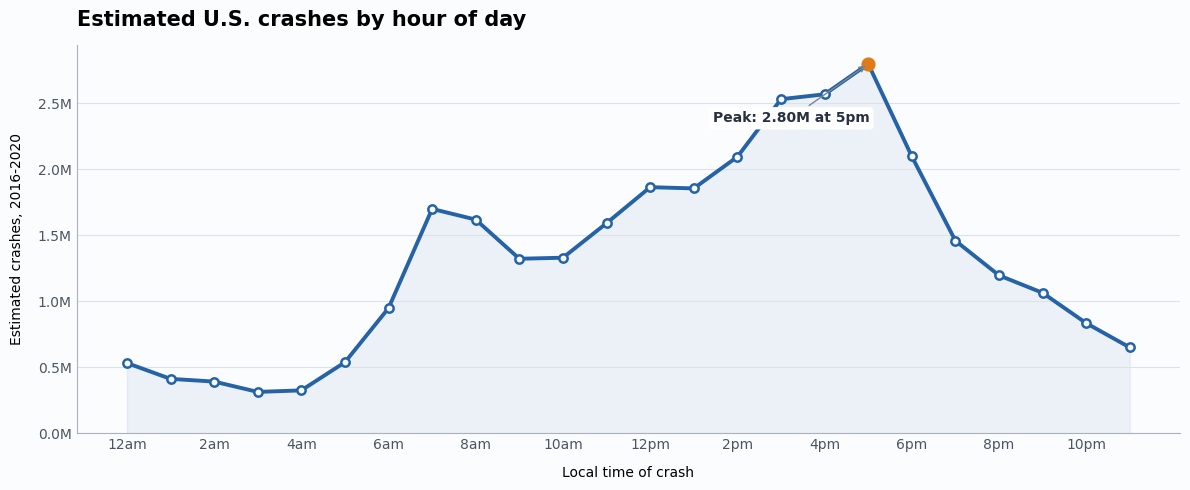

In [8]:
volume_peak = hour_summary.loc[hour_summary["estimated_crashes"].idxmax()]

fig, ax = plt.subplots(figsize=(12, 5), facecolor="#FBFCFE")
ax.set_facecolor("#FBFCFE")
ax.plot(
    hour_summary["HOUR_IM"],
    hour_summary["estimated_crashes"],
    color="#2563A6",
    marker="o",
    markerfacecolor="#FBFCFE",
    markeredgewidth=1.8,
    linewidth=2.8,
    markersize=6,
)
ax.fill_between(
    hour_summary["HOUR_IM"],
    hour_summary["estimated_crashes"],
    color="#2563A6",
    alpha=0.07,
)
ax.scatter(
    volume_peak["HOUR_IM"],
    volume_peak["estimated_crashes"],
    color="#E07A18",
    s=85,
    zorder=3,
)
ax.annotate(
    f'Peak: {volume_peak["estimated_crashes"] / 1_000_000:.2f}M at {format_hour(int(volume_peak["HOUR_IM"]))}',
    xy=(volume_peak["HOUR_IM"], volume_peak["estimated_crashes"]),
    xytext=(-112, -42),
    textcoords="offset points",
    fontsize=10,
    fontweight="semibold",
    color="#273142",
    bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "none"},
    arrowprops={"arrowstyle": "->", "color": "#7B8491"},
)
ax.set_title(
    "Estimated U.S. crashes by hour of day",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel("Local time of crash", labelpad=10)
ax.set_ylabel("Estimated crashes, 2016-2020", labelpad=10)
ax.set_xticks(tick_hours, tick_labels)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:.1f}M"))
ax.grid(axis="y", color="#DDE2E8", linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#AAB2BD")
ax.tick_params(colors="#4B5563", length=0)
fig.tight_layout()
plt.show()

#### When are crashes most likely to be severe?

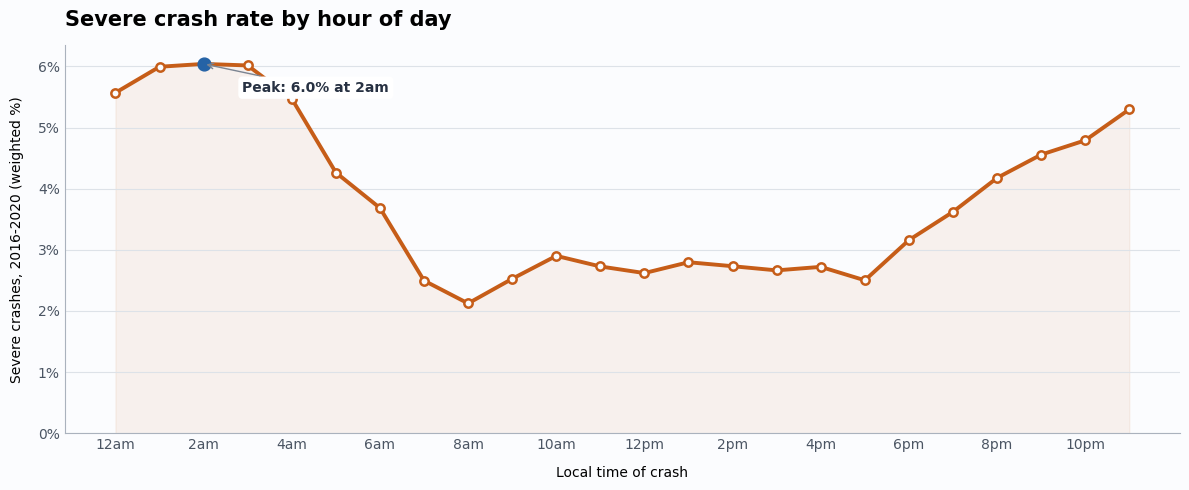

In [9]:
severity_peak = hour_summary.loc[hour_summary["severe_rate"].idxmax()]

fig, ax = plt.subplots(figsize=(12, 5), facecolor="#FBFCFE")
ax.set_facecolor("#FBFCFE")
ax.plot(
    hour_summary["HOUR_IM"],
    hour_summary["severe_rate"],
    color="#C65D18",
    marker="o",
    markerfacecolor="#FBFCFE",
    markeredgewidth=1.8,
    linewidth=2.8,
    markersize=6,
)
ax.fill_between(
    hour_summary["HOUR_IM"],
    hour_summary["severe_rate"],
    color="#C65D18",
    alpha=0.07,
)
ax.scatter(
    severity_peak["HOUR_IM"],
    severity_peak["severe_rate"],
    color="#2563A6",
    s=85,
    zorder=3,
)
ax.annotate(
    f'Peak: {severity_peak["severe_rate"]:.1%} at {format_hour(int(severity_peak["HOUR_IM"]))}',
    xy=(severity_peak["HOUR_IM"], severity_peak["severe_rate"]),
    xytext=(28, -20),
    textcoords="offset points",
    fontsize=10,
    fontweight="semibold",
    color="#273142",
    bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "none"},
    arrowprops={"arrowstyle": "->", "color": "#7B8491"},
)
ax.set_title(
    "Severe crash rate by hour of day",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel("Local time of crash", labelpad=10)
ax.set_ylabel("Severe crashes, 2016-2020 (weighted %)", labelpad=10)
ax.set_xticks(tick_hours, tick_labels)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.grid(axis="y", color="#DDE2E8", linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#AAB2BD")
ax.tick_params(colors="#4B5563", length=0)
fig.tight_layout()
plt.show()